# MS COCO Classification Challenge Report

To run this notebook successfully, you need to have the MS COCO dataset downloaded and every python package installed. All python requirements are listed in the appropriate files given in the zip file and was created using uv. You can also create an.env file to provide different variables to the notebook using .env.example as a template. The notebook is structured in several sections, each of them being a code cell or a Markdown cell. You can run the notebook cell by cell, or you can run all cells at once.

## 1. Installation and imports

We begin by importing the required libraries. We also check the Python and PyTorch versions and initialize the device used for computation. Setting `DEVICE` in `.env` is optional: when it is not specified, the notebook automatically selects the best available accelerator. If necessary, `DIR_PATH` can also be set in `.env` to define the execution directory.

In [1]:
import os
import torch
import torch.nn as nn
import torchvision
import platform
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
import copy

from dotenv import load_dotenv
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score

pwd = ""
#pwd = os.getenv("DIR_PATH", "/Users/ProjetPIR/PR_CR/theo/model")
os.chdir(pwd) if pwd else None

import sys

PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

from lib.util import CLASSES, COCOTrainImageDataset, COCOTestImageDataset, TransformSubset, AsymmetricLoss

load_dotenv()

# device initialization
device_name = os.getenv("DEVICE", "")
DEVICE = torch.device(
    device_name) if device_name else (
    torch.accelerator.current_accelerator()) if (
    torch.accelerator.is_available()) else (
    torch.device("cpu"))

print("Python :", platform.python_version())
print("PyTorch :", torch.__version__)
print("Device used :", DEVICE)
print("Execution directory :", os.getcwd())

Python : 3.14.0
PyTorch : 2.14.1+cu132
Device used : cuda
Execution directory : C:\Users\theof\PycharmProjects\iav


## 2. Configuration

This section defines the data and output paths as well as the main training hyperparameters. Set `DATA_ROOT` to the location of the MS COCO dataset, either through `.env` or directly in the cell below. We also define the number of epochs, batch size, learning rate, random seed, and an optional quick-run mode for development.

In [2]:
# Defining global variables for data directories
DATA_ROOT = Path(os.getenv("DATA_ROOT", "/opt/iav/labs/data"))
DATA_ROOT = DATA_ROOT / "ms-coco"
IMAGE_DIR = DATA_ROOT / "images/train"
LABEL_DIR = DATA_ROOT / "labels/train"
TEST_IMAGE_DIR = DATA_ROOT / "images/test"

# Defining global variables for output directories
#OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output"))
OUTPUT_DIR = Path("output_last")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTPUT_DIR / os.getenv("JSON_PATH", "submission.json")

SEED = 30
EPOCHS = 20
BATCH_SIZE = 32
NUM_WORKERS = min(8, os.cpu_count() or 1)
IMAGE_SIZE = 224
PATIENCE = 3
TRANSFORM = True

# Oversampling of images containing rare classes (Repeat Factor Sampling)
OVERSAMPLE = True
RFS_THRESHOLD = 0.01

# Fraction of the dataset to be used for validation
VAL_FRACTION = 0.15

# Probability threshold above which a class is predicted
THRESHOLD = 0.5

# For a quick run, you can set QUICK_RUN to True and limit the number of images processed
QUICK_RUN = False
QUICK_MAX_IMAGES = 5000

# Pin memory for faster data transfer to GPU if using CUDA
PIN_MEMORY = DEVICE.type == "cuda"


# Function to set random seed for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = (DEVICE.type == "cuda")


set_seed()

print("Images :", IMAGE_DIR.resolve())
print("Annotations :", LABEL_DIR.resolve())
print("Test images :", TEST_IMAGE_DIR.resolve())
print("Outputs :", OUTPUT_DIR.resolve())
print("Submission :", JSON_PATH.resolve())

Images : C:\Users\theof\PycharmProjects\iav\data\ms-coco\images\train
Annotations : C:\Users\theof\PycharmProjects\iav\data\ms-coco\labels\train
Test images : C:\Users\theof\PycharmProjects\iav\data\ms-coco\images\test
Outputs : C:\Users\theof\PycharmProjects\iav\output_last
Submission : C:\Users\theof\PycharmProjects\iav\output_last\output\submission.json


## 3. Class definitions and file verification

We define the class list and verify access to the images and annotation files. The number of images and annotations should normally match, and an example of each file type is displayed through the diagnostic output.

In [3]:
classes = CLASSES
NUM_CLASSES = len(classes)
assert NUM_CLASSES == 80, f"We expect to find 80 classes but {NUM_CLASSES} were found."

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset not found. Verify DATA_ROOT={DATA_ROOT.resolve()} ; "
        f"There must be a folder 'images/train' and a folder 'labels/train' containing the .jpg images and .cls annotation files respectively."
    )

test_images = sorted(IMAGE_DIR.glob("*.jpg"))
label_files = sorted(LABEL_DIR.glob("*.cls"))

if not test_images:
    raise RuntimeError("No .jpg files found in IMAGE_DIR.")
if not label_files:
    raise RuntimeError("No .cls files found in LABEL_DIR.")

print(f"Images : {len(test_images):,}")
print(f"Annotated files : {len(label_files):,}")
print("Image example :", test_images[0].name if test_images else None)
print("annotation example :", label_files[0].name if label_files else None)

if len(test_images) != len(label_files):
    print(
        f"Warning: Number of images ({len(test_images)}) does not match number of labels ({len(label_files)}). Some images may not have corresponding labels or vice versa.")

Images : 65,000
Annotated files : 65,000
Image example : 000000000009.jpg
annotation example : 000000000009.cls


## 4. Annotation analysis

Before training, we analyze the class distribution to characterize the dataset and identify potential imbalance issues.

Annotations analysis:   0%|          | 0/65000 [00:00<?, ?it/s]

Images analysed : 65000
Annotations problematic : 0
Average number of classes/image : 2.926
Median : 2.0
Min :  1
Max :  18


,class,images_positives
78,hair drier,102
70,toaster,117
12,parking meter,396
21,bear,516
76,scissors,555
...,...,...
41,cup,5057
60,dining table,6546
2,car,6811
56,chair,7043


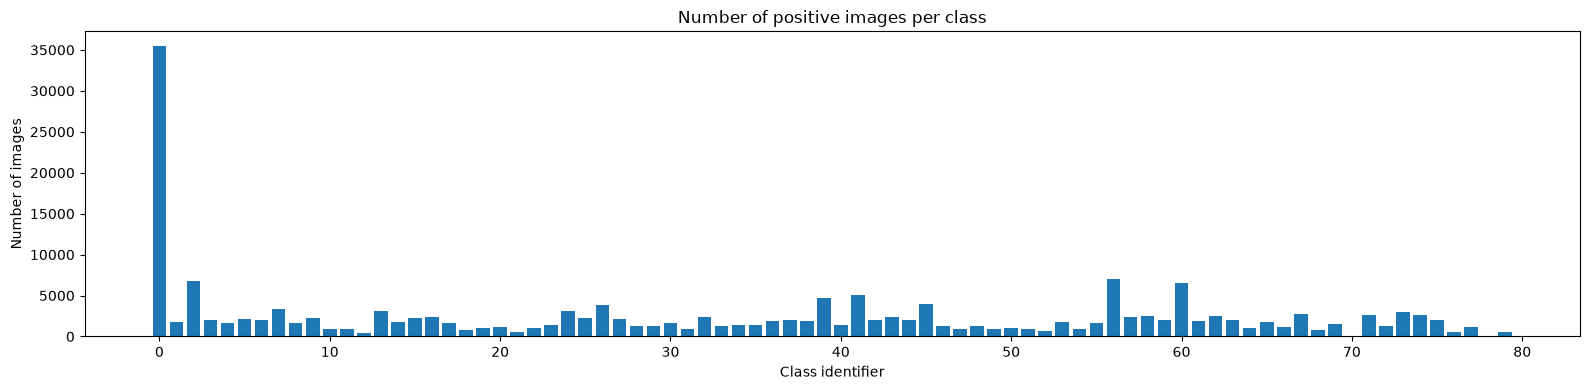

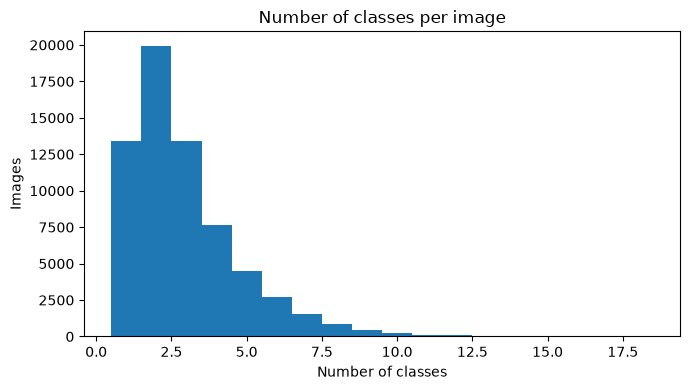

In [4]:
scan_files = label_files[:QUICK_MAX_IMAGES] if QUICK_RUN else label_files
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
labels_per_image = []
invalid_rows = []

for p in tqdm(scan_files, desc="Annotations analysis"):
    try:
        ids = [int(x.strip()) for x in p.read_text().splitlines() if x.strip()]
        if any(i < 0 or i >= NUM_CLASSES for i in ids):
            invalid_rows.append(p.name)
            continue
        class_counts[np.unique(ids)] += 1
        labels_per_image.append(len(set(ids)))
    except Exception as e:
        print(f"Error processing {p.name}: {e}")
        invalid_rows.append(p.name)

print("Images analysed :", len(scan_files))
print("Annotations problematic :", len(invalid_rows))
print("Average number of classes/image :", round(float(np.mean(labels_per_image)), 3))
print("Median :", float(np.median(labels_per_image)))
print("Min : ", min(labels_per_image))
print("Max : ", max(labels_per_image))

# Displaying the distribution of images per class in a DataFrame
freq_df = pd.DataFrame({"class": classes, "images_positives": class_counts})
display(freq_df.sort_values("images_positives"))

# Distribution of the number of images per class
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), class_counts)
plt.title("Number of positive images per class")
plt.xlabel("Class identifier")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

# Distribution of the number of classes per image
plt.figure(figsize=(7, 4))
plt.hist(labels_per_image, bins=range(1, max(labels_per_image) + 2), align="left")
plt.title("Number of classes per image")
plt.xlabel("Number of classes")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

The class distribution is highly imbalanced. The `person` class is by far the most represented, with approximately 37,000 positive images, while classes such as `hair drier` and `toaster` have only around 100 images. This imbalance may bias the model toward frequent classes and make rare classes difficult to learn. Each image contains approximately three classes on average, while the median is two, which confirms that this is a multi-label problem with a relatively small number of positive classes per image.

## 5. PyTorch dataset

The PyTorch dataset classes for training and testing are defined in `lib/util.py` and imported at the beginning of the notebook. They load images and annotations, apply the selected transformations, and prepare the tensors required for training and evaluation.

## 6. Train/validation split and oversampling of rare classes

The dataset is split into training and validation subsets according to `VAL_FRACTION`, with a fixed seed so that the split is identical at every run. The validation subset is never used for training.

The class distribution analysed in section 4 is strongly imbalanced, and data augmentation alone does not change it: the augmentation is applied on the fly, so the model sees a different version of every image at each epoch, but the number of images per class stays the same.

To give more weight to the underrepresented classes, we use [Repeat Factor Sampling](https://www.emergentmind.com/topics/repeat-factor-sampling-rfs) on the training subset only. Each class $c$ gets a repeat factor

$$r_c = \max\left(1, \sqrt{\frac{t}{f_c}}\right)$$

where $f_c$ is the fraction of training images containing the class $c$ and $t$ is the threshold `RFS_THRESHOLD`. Each image $i$ is then repeated according to the factor of its rarest class:

$$r_i = \max_{c \in i} r_c$$

The image is repeated $\lfloor r_i \rfloor$ times, plus one extra time with probability $r_i - \lfloor r_i \rfloor$. Since every copy goes through the random augmentation of the next section, the duplicated images are all different. The validation subset is left untouched, so the thresholds tuned on it remain valid for the real class distribution. Setting `OVERSAMPLE = False` disables the oversampling.

In [5]:
max_images = QUICK_MAX_IMAGES if QUICK_RUN else None
base_dataset = COCOTrainImageDataset(IMAGE_DIR, LABEL_DIR, transform=None, maximum_images=max_images)
n_val = max(1, int(len(base_dataset) * VAL_FRACTION))
n_train = len(base_dataset) - n_val
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = torch.utils.data.random_split(base_dataset, [n_train, n_val], generator=generator)

train_targets = np.zeros((len(train_subset), NUM_CLASSES), dtype=np.float32)
for k, idx in enumerate(train_subset.indices):
    ids = [int(x) for x in base_dataset.img_labels[idx].read_text().split()]
    train_targets[k, ids] = 1

freq = train_targets.mean(axis=0)
r_c = np.maximum(1.0, np.sqrt(RFS_THRESHOLD / np.maximum(freq, 1e-12)))
r_i = (train_targets * r_c).max(axis=1).clip(min=1.0)
rng = np.random.default_rng(SEED)
reps = np.floor(r_i).astype(int) + (rng.random(len(r_i)) < r_i - np.floor(r_i))
if not OVERSAMPLE:
    reps = np.ones(len(train_subset), dtype=int)

expanded = np.repeat(np.arange(len(train_subset)), reps)
train_targets_seen = train_targets[expanded]
train_source = torch.utils.data.Subset(base_dataset, np.array(train_subset.indices)[expanded].tolist())

print(f"Train : {len(train_subset):,} -> {len(train_source):,} after oversampling | Validation : {len(val_subset):,}")

Train : 55,250 -> 55,748 after oversampling | Validation : 9,750


## 7. Effect of the oversampling on the class distribution

To check what the Repeat Factor Sampling actually changes, we count, for every class, the number of positive images in the training subset before and after the oversampling. The table lists the 15 rarest classes with their multiplication ratio, and the bar chart shows all 80 classes sorted by frequency on a log scale: the orange bars are the original counts and the blue bars behind them the counts after oversampling, so the visible blue part is what the oversampling adds.

The rarest classes are repeated the most, since their repeat factor `sqrt(t / f_c)` is the largest, while the frequent classes such as `person` stay almost unchanged. Their count still increases a little, because an image is repeated as a whole: a rare object is often seen next to frequent ones, and all its labels are copied with it. The oversampling therefore reduces the imbalance without removing it, which is why threshold tuning and imbalance-aware losses are still evaluated later.

,class,before,after,ratio
78,hair drier,92,223,2.42
70,toaster,103,233,2.26
12,parking meter,343,452,1.32
21,bear,426,487,1.14
76,scissors,470,512,1.09
79,toothbrush,480,529,1.10
52,hot dog,584,584,1.00
18,sheep,679,680,1.00
68,microwave,702,756,1.08
54,donut,722,724,1.00


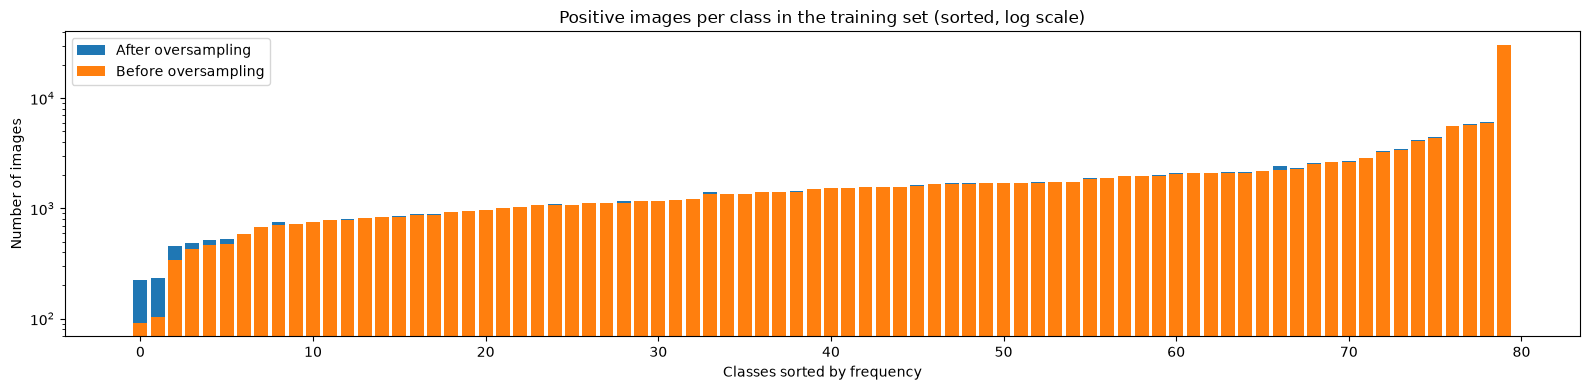

In [6]:
oversampling_df = pd.DataFrame({"class": classes,
                                "before": train_targets.sum(axis=0).astype(int),
                                "after": train_targets_seen.sum(axis=0).astype(int)})
oversampling_df["ratio"] = (oversampling_df["after"] / oversampling_df["before"].clip(lower=1)).round(2)
display(oversampling_df.sort_values("before").head(15))

order = np.argsort(train_targets.sum(axis=0))
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), oversampling_df["after"].values[order], label="After oversampling")
plt.bar(np.arange(NUM_CLASSES), oversampling_df["before"].values[order], label="Before oversampling")
plt.yscale("log")
plt.title("Positive images per class in the training set (sorted, log scale)")
plt.xlabel("Classes sorted by frequency")
plt.ylabel("Number of images")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Transformations and data loaders

We define the image transformations and create the training and validation datasets and data loaders. Since the original COCO dataset class does not support separate transformations for both splits, `TransformSubset` applies distinct training and validation transformations. The training images (including the copies created by the oversampling) go through a random crop, flip and color jitter, drawn again each time an image is loaded. The validation images are only resized and normalized. When `TRANSFORM` is disabled, both subsets are only resized.

In [7]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

resize_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

train_ds = TransformSubset(train_source, train_transform if TRANSFORM else resize_transform)
val_ds = TransformSubset(val_subset, val_transform if TRANSFORM else resize_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                        persistent_workers=NUM_WORKERS > 0)

print(f"Train : {len(train_ds):,} | Validation : {len(val_ds):,}")

Train : 55,748 | Validation : 9,750


## 9. Metric computation

We define the evaluation metrics used throughout the experiments. F1 score, precision, and recall are the main metrics, using both the standard `sklearn.metrics` implementations and the competition-specific inverse-frequency weighted F1. These metrics allow us to compare models before selecting a final submission model.

In [8]:
def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def compute_class_metrics(class_prec, class_recall):
    class_results = []
    for p, r in zip(class_prec, class_recall):
        f1 = (0 if p == r == 0 else 2. / (1 / p + 1 / r))
        class_results.append({"f1": f1, "precision": p, "recall": r})
    return class_results


@torch.no_grad()
def predict_loader(model, loader, device=DEVICE):
    model.eval()
    probs_all, targets_all = [], []
    for images, targets in tqdm(loader, leave=False):
        logits = model(images.to(device, non_blocking=True))
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        targets_all.append(targets.numpy())
    return np.concatenate(targets_all), np.concatenate(probs_all)


def inverse_frequency_weighted_f1(y_true, y_pred):
    positives = y_true.sum(axis=0)
    tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0)
    fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    recall = np.divide(tp, positives, out=np.zeros_like(tp, dtype=float), where=positives > 0)
    weights = np.divide(1.0, positives, out=np.zeros_like(positives, dtype=float), where=positives > 0)
    if weights.sum() == 0: return 0.0
    weights = weights / weights.sum()
    p, r = np.sum(precision * weights), np.sum(recall * weights)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.uint8)
        rows.append({
            "threshold": round(float(t), 2),
            "f1_leaderboard": inverse_frequency_weighted_f1(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        })
    sweep_df = pd.DataFrame(rows)
    best = sweep_df.loc[sweep_df["f1_leaderboard"].idxmax()]
    return sweep_df, best

## 10. Pretrained architectures, losses, and model construction

This section centralizes model construction. For convolutional networks, we compare ResNet-18 and ResNet-50 with and without ImageNet pretraining and with either a trainable or frozen backbone. EfficientNet-B0 is also included as an additional CNN baseline. We additionally test ViT-B/16 and Swin-T as Transformer architectures.

The classification problem is multi-label and strongly imbalanced. In addition to binary cross-entropy (BCE) and a positive-class-weighted BCE, we include Asymmetric Loss (ASL). ASL down-weights easy negative examples and applies different focusing parameters to positive and negative labels, which makes it a relevant candidate when each image has only a few positive classes among 80 possible classes.

In [9]:
def build_model(backbone="resnet18", pretrained=True, freeze_backbone=False):
    if backbone == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
        head_prefix = "fc."
    elif backbone == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
        head_prefix = "fc."
    elif backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
        head_prefix = "classifier."
    elif backbone == "vit_b_16":
        weights = models.ViT_B_16_Weights.DEFAULT if pretrained else None
        model = models.vit_b_16(weights=weights)
        model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
        head_prefix = "heads."
    elif backbone == "swin_t":
        weights = models.Swin_T_Weights.DEFAULT if pretrained else None
        model = models.swin_t(weights=weights)
        model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
        head_prefix = "head."
    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    if freeze_backbone:
        for name, parameter in model.named_parameters():
            parameter.requires_grad = name.startswith(head_prefix)
    return model.to(DEVICE)


def make_criterion(loss_name, train_targets=None):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    if loss_name == "weighted_bce":
        if train_targets is None:
            raise ValueError("Train targets are required for weighted_bce")
        pos = train_targets.sum(axis=0)
        neg = len(train_targets) - pos
        pos_weight = torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32, device=DEVICE)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    if loss_name == "asl":
        return AsymmetricLoss(gamma_neg=4.0, gamma_pos=1.0, clip=0.05)
    raise ValueError(f"Unknown loss function: {loss_name}")

## 11. Training and evaluation loop

This section defines the training loop used for all experiments. After each epoch, the model is evaluated on the validation set. We save the checkpoint with the lowest validation loss and use early stopping to limit overfitting. The same evaluation protocol is used for every architecture and loss function.

In [10]:
def fit_experiment(name, backbone="resnet18", pretrained=True, freeze_backbone=False, loss_name="bce", lr=1e-4,
                   epochs=EPOCHS):
    model = build_model(backbone, pretrained, freeze_backbone)

    criterion = make_criterion(loss_name, train_targets_seen)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)
    best_loss, best_state, stale = float("inf"), None, 0
    history = []
    start = time.time()

    for epoch in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for images, targets in tqdm(train_loader, desc=f"{name} - epoch {epoch + 1}/{epochs}", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0)
            seen += images.size(0)

        y_val, p_val = predict_loader(model, val_loader)
        model.eval()
        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                batch_loss = criterion(model(images), targets)
                total_loss += batch_loss.item() * images.size(0)
                total_n += images.size(0)
        val_loss = total_loss / max(total_n, 1)
        metrics = compute_metrics(y_val, p_val, threshold=THRESHOLD)
        scheduler.step(val_loss)
        row = {"experiment": name, "epoch": epoch + 1, "train_loss": running / max(seen, 1),
               "val_loss": val_loss, **metrics, "lr": optimizer.param_groups[0]["lr"]}
        history.append(row)
        print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in row.items()})
        if val_loss < best_loss:
            best_loss, stale = val_loss, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({"model_state_dict": best_state, "backbone": backbone,
                        "pretrained": pretrained, "freeze_backbone": freeze_backbone,
                        "loss_name": loss_name, "threshold": THRESHOLD, "classes": list(classes)},
                       OUTPUT_DIR / f"{name}_best.pt")
        else:
            stale += 1
            if stale >= PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, p_val = predict_loader(model, val_loader)
    summary = {"experiment": name, "backbone": backbone, "pretrained": pretrained,
               "freeze_backbone": freeze_backbone, "loss": loss_name, "lr": lr,
               "epochs_run": len(history), "best_val_loss": best_loss,
               **compute_metrics(y_val, p_val, THRESHOLD),
               "inverse_frequency_weighted_f1": inverse_frequency_weighted_f1(
                   y_val, (p_val >= THRESHOLD).astype(np.uint8)),
               "seconds": time.time() - start}
    return model, pd.DataFrame(history), summary, y_val, p_val

## 12. Experiments

We define the models and loss functions to compare. Each configuration is trained for the selected number of epochs and evaluated on the validation set. Checkpoints, training histories, validation predictions, and summary metrics are stored so that all configurations can be analyzed before selecting the final model.

In [13]:
EXPERIMENTS = [
    # ResNet-18 ablation: initialization and backbone freezing.
    {"name": "resnet18_pretrained_finetune", "backbone": "resnet18", "pretrained": True,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "resnet18_pretrained_frozen", "backbone": "resnet18", "pretrained": True,
     "freeze_backbone": True, "loss_name": "bce", "lr": 5e-4},
    {"name": "resnet18_scratch_finetune", "backbone": "resnet18", "pretrained": False,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},

    # Comparison with larger CNNs and imbalance-aware losses.
    {"name": "resnet50_pretrained_finetune", "backbone": "resnet50", "pretrained": True,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "resnet18_weighted_bce", "backbone": "resnet18", "pretrained": True,
     "freeze_backbone": False, "loss_name": "weighted_bce", "lr": 1e-4},
    {"name": "resnet18_asl", "backbone": "resnet18", "pretrained": True,
     "freeze_backbone": False, "loss_name": "asl", "lr": 1e-4},
    {"name": "efficientnet_b0_pretrained", "backbone": "efficientnet_b0", "pretrained": True,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},

    # Transformer models for comparison with convolutional architectures.
    {"name": "vit_b16_pretrained", "backbone": "vit_b_16", "pretrained": True,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-5},
    {"name": "swin_t_pretrained", "backbone": "swin_t", "pretrained": True,
     "freeze_backbone": False, "loss_name": "bce", "lr": 1e-5},

    {"name": "resnet50_pretrained_finetune", "backbone": "resnet50", "pretrained": True,
     "freeze_backbone": False, "loss_name": "weighted_bce", "lr": 1e-4},
]

# For a fast execution, uncomment the following line.
EXPERIMENTS = EXPERIMENTS[-1:]

experiment_results = []
histories = {}
prediction_cache = {}
models_cache = {}

for cfg in EXPERIMENTS:
    model, hist, summary, y_val, p_val = fit_experiment(**cfg, epochs=EPOCHS)
    experiment_results.append(summary)
    histories[cfg["name"]] = hist
    prediction_cache[cfg["name"]] = (y_val, p_val)
    models_cache[cfg["name"]] = model
    pd.DataFrame(experiment_results).to_csv(OUTPUT_DIR / "experiment_results_partial.csv", index=False)

results_df = pd.DataFrame(experiment_results).sort_values("f1_macro", ascending=False)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "experiment_results.csv", index=False)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\theof/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth



  0%|          | 0.00/97.8M [00:00<?, ?B/s]
  2%|▏         | 1.88M/97.8M [00:00<00:05, 19.6MB/s]
  4%|▍         | 4.00M/97.8M [00:00<00:05, 19.3MB/s]
  7%|▋         | 7.12M/97.8M [00:00<00:04, 22.1MB/s]
 11%|█         | 10.5M/97.8M [00:00<00:03, 25.9MB/s]
 14%|█▍        | 13.8M/97.8M [00:00<00:03, 28.4MB/s]
 17%|█▋        | 16.5M/97.8M [00:00<00:03, 28.3MB/s]
 20%|█▉        | 19.2M/97.8M [00:00<00:03, 24.4MB/s]
 22%|██▏       | 21.8M/97.8M [00:00<00:03, 24.0MB/s]
 26%|██▌       | 25.4M/97.8M [00:01<00:02, 27.7MB/s]
 29%|██▉       | 28.8M/97.8M [00:01<00:02, 26.5MB/s]
 34%|███▎      | 32.9M/97.8M [00:01<00:02, 27.8MB/s]
 36%|███▋      | 35.6M/97.8M [00:01<00:02, 25.7MB/s]
 39%|███▉      | 38.5M/97.8M [00:01<00:02, 24.4MB/s]
 44%|████▎     | 42.6M/97.8M [00:01<00:02, 28.8MB/s]
 47%|████▋     | 45.5M/97.8M [00:01<00:01, 28.1MB/s]
 50%|████▉     | 48.5M/97.8M [00:01<00:01, 28.8MB/s]
 53%|█████▎    | 51.4M/97.8M [00:02<00:01, 26.1MB/s]
 56%|█████▌    | 54.8M/97.8M [00:02<00:01, 28.2MB/s]
 

resnet50_pretrained_finetune - epoch 1/20:   0%|          | 0/1743 [00:20<?, ?it/s]

  0%|          | 0/305 [00:19<?, ?it/s]

{'experiment': 'resnet50_pretrained_finetune', 'epoch': 1, 'train_loss': 0.5435, 'val_loss': 0.4231, 'f1_macro': 0.3968, 'f1_micro': 0.4186, 'precision_macro': 0.2738, 'recall_macro': 0.9043, 'lr': 0.0001}


...

resnet50_pretrained_finetune - epoch 10/20:   0%|          | 0/1743 [00:00<?, ?it/s]

  0%|          | 0/305 [00:00<?, ?it/s]

{'experiment': 'resnet50_pretrained_finetune', 'epoch': 10, 'train_loss': 0.1896, 'val_loss': 0.4842, 'f1_macro': 0.5667, 'f1_micro': 0.5891, 'precision_macro': 0.4444, 'recall_macro': 0.846, 'lr': 0.0}
Early stopping triggered.


  0%|          | 0/305 [00:00<?, ?it/s]

,experiment,backbone,pretrained,freeze_backbone,loss,lr,epochs_run,best_val_loss,f1_macro,f1_micro,precision_macro,recall_macro,inverse_frequency_weighted_f1,seconds
0,resnet50_pretrained_finetune,resnet50,True,False,weighted_bce,0.0001,10,0.390363,0.463693,0.491444,0.332724,0.892651,0.347819,3857.221294


## 13. Results visualization

We visualize the validation loss and summarize the metrics for every experiment. This makes it possible to compare the architectures, initialization strategies, backbone freezing, and loss functions before any test-set submission is generated.

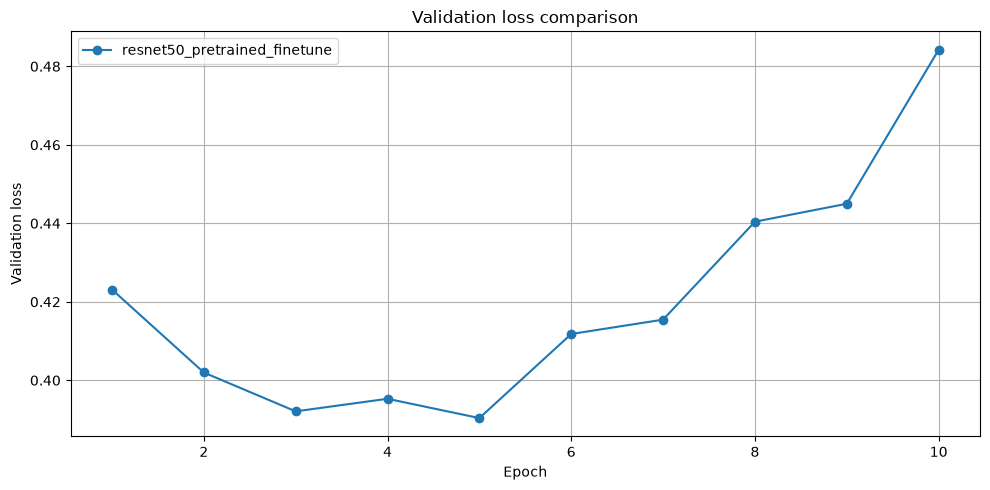

,experiment,f1_macro,f1_micro,precision_macro,recall_macro,inverse_frequency_weighted_f1,best_val_loss,seconds
0,resnet50_pretrained_finetune,0.463693,0.491444,0.332724,0.892651,0.347819,0.390363,3857.221294


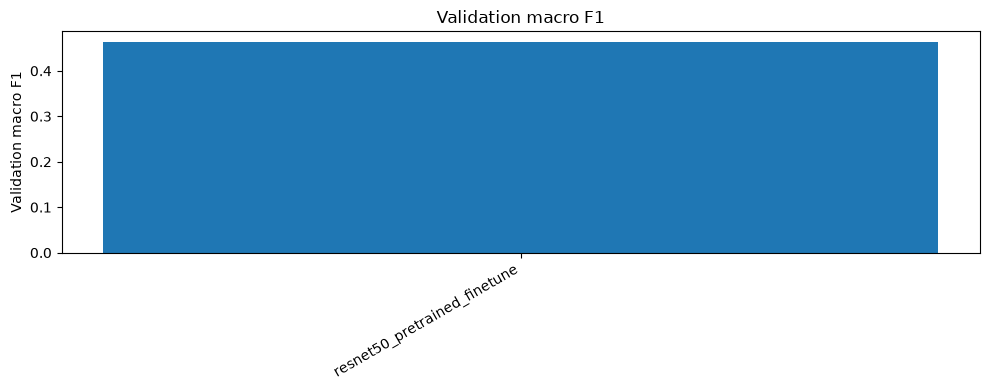

In [14]:
if histories:
    plt.figure(figsize=(10, 5))
    for name, hist in histories.items():
        plt.plot(hist["epoch"], hist["val_loss"], marker="o", label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Validation loss")
    plt.title("Validation loss comparison")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if not results_df.empty:
    display(results_df[["experiment", "f1_macro", "f1_micro", "precision_macro",
                        "recall_macro", "inverse_frequency_weighted_f1", "best_val_loss", "seconds"]])
    plt.figure(figsize=(10, 4))
    plt.bar(results_df["experiment"], results_df["f1_macro"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Validation macro F1")
    plt.title("Validation macro F1")
    plt.tight_layout()
    plt.show()

## 14. Threshold tuning

A threshold of 0.5 is rarely optimal for an imbalanced multi-label problem. For every trained model, we evaluate a range of thresholds on the validation set and select the value that maximizes the chosen validation metric. Threshold tuning is performed independently for each model before the final comparison.

In [15]:
def search_global_threshold(y_true, y_prob, metric="f1_macro"):
    candidates = np.arange(0.10, 0.91, 0.05)
    rows = []
    for th in candidates:
        rows.append({"threshold": float(th), **compute_metrics(y_true, y_prob, float(th)),
                     "f1_leaderboard": inverse_frequency_weighted_f1(
                         y_true, (y_prob >= th).astype(np.uint8))})
    frame = pd.DataFrame(rows)
    best = frame.sort_values(metric, ascending=False).iloc[0]
    return float(best["threshold"]), frame


def search_per_class_thresholds(y_true, y_prob):
    candidates = np.arange(0.10, 0.91, 0.05)
    thresholds = np.full(y_true.shape[1], 0.5, dtype=float)
    for c in range(y_true.shape[1]):
        if y_true[:, c].sum() == 0:
            continue
        scores = [f1_score(y_true[:, c], y_prob[:, c] >= th, zero_division=0) for th in candidates]
        thresholds[c] = float(candidates[int(np.argmax(scores))])
    return thresholds


threshold_tables = {}
threshold_summaries = []
for name, (y_true_model, y_prob_model) in prediction_cache.items():
    threshold, table = search_global_threshold(y_true_model, y_prob_model, metric="f1_macro")
    threshold_tables[name] = table
    threshold_summaries.append({
        "experiment": name,
        "best_threshold": threshold,
        **compute_metrics(y_true_model, y_prob_model, threshold),
        "f1_leaderboard": inverse_frequency_weighted_f1(
            y_true_model, (y_prob_model >= threshold).astype(np.uint8)),
    })

threshold_results_df = pd.DataFrame(threshold_summaries).sort_values("f1_macro", ascending=False)
display(threshold_results_df)
threshold_results_df.to_csv(OUTPUT_DIR / "threshold_comparison.csv", index=False)

best_name = threshold_results_df.iloc[0]["experiment"]
best_model = models_cache[best_name]
y_val, p_val = prediction_cache[best_name]
best_global_threshold = float(threshold_results_df.iloc[0]["best_threshold"])
per_class_thresholds = search_per_class_thresholds(y_val, p_val)

print("Best configuration found :", best_name)
print("Best Threshold found :", best_global_threshold)
print("Metrics when threshold=0.5 :", compute_metrics(y_val, p_val, 0.5))
print("Metrics when threshold=best_global_threshold :", compute_metrics(y_val, p_val, best_global_threshold))
display(threshold_tables[best_name])

,experiment,best_threshold,f1_macro,f1_micro,precision_macro,recall_macro,f1_leaderboard
0,resnet50_pretrained_finetune,0.9,0.619205,0.652575,0.591974,0.694459,0.496468


Best configuration found : resnet50_pretrained_finetune
Best Threshold found : 0.9000000000000002
Metrics when threshold=0.5 : {'f1_macro': 0.46369307112623853, 'f1_micro': 0.4914437712427959, 'precision_macro': 0.33272423978085, 'recall_macro': 0.892650647004994}
Metrics when threshold=best_global_threshold : {'f1_macro': 0.6192052914583657, 'f1_micro': 0.6525745065381481, 'precision_macro': 0.5919744397309759, 'recall_macro': 0.6944594149191967}


,threshold,f1_macro,f1_micro,precision_macro,recall_macro,f1_leaderboard
0,0.10,0.248423,0.257660,0.150383,0.977706,0.171903
1,0.15,0.287732,0.297306,0.179413,0.967381,0.203337
2,0.20,0.320152,0.331103,0.204502,0.956828,0.228672
3,0.25,0.348607,0.361537,0.227552,0.946110,0.251368
4,0.30,0.373912,0.389707,0.248815,0.936196,0.272074
5,0.35,0.397535,0.416175,0.269515,0.926691,0.291515
6,0.40,0.420197,0.442028,0.290366,0.914907,0.310155
7,0.45,0.442396,0.467214,0.311317,0.905212,0.329253
8,0.50,0.463693,0.491444,0.332724,0.892651,0.347819
9,0.55,0.484620,0.514905,0.354783,0.880294,0.366094


## 15. Per-class metrics

After selecting the validation threshold, we compute precision, recall, and F1 score for every class. This provides a more detailed view of model behavior, especially for rare classes affected by the strong class imbalance. The results are saved to a CSV file for the final analysis.

In [16]:
y_pred = (p_val >= best_global_threshold).astype(np.uint8)
per_class = []
for c, name in enumerate(classes):
    per_class.append({
        "class": name, "positifs_validation": int(y_val[:, c].sum()),
        "precision": precision_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "recall": recall_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "f1": f1_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "threshold_per_class": per_class_thresholds[c]
    })
per_class_df = pd.DataFrame(per_class).sort_values("f1")
display(per_class_df.head(20))
per_class_df.to_csv(OUTPUT_DIR / "per_class_validation_metrics.csv", index=False)

,class,positifs_validation,precision,recall,f1,threshold_per_class
78,hair drier,10,0.054348,0.500000,0.098039,0.80
70,toaster,14,0.080357,0.642857,0.142857,0.90
76,scissors,85,0.215596,0.552941,0.310231,0.90
12,parking meter,53,0.227778,0.773585,0.351931,0.90
24,backpack,483,0.359768,0.385093,0.372000,0.85
26,handbag,544,0.497449,0.358456,0.416667,0.80
67,cell phone,392,0.401826,0.448980,0.424096,0.85
79,toothbrush,81,0.315476,0.654321,0.425703,0.90
13,bench,443,0.433628,0.442438,0.437989,0.90
40,wine glass,222,0.401961,0.554054,0.465909,0.90


## 16. Comparative model analysis

Validation metrics and threshold curves are computed for every model, while only the configuration selected after this comparison is used to generate the submission. This separation makes the final report reproducible and allows us to discuss the trade-offs between the approaches. ImageNet pretraining generally provides a stronger starting point, freezing the backbone reduces computational cost but limits domain adaptation, ResNet-50 increases representational capacity at the cost of training time, and Transformers can model global context but are more expensive and more sensitive to data size and learning-rate choices. ASL is specifically evaluated because it may improve the treatment of the many easy negative labels in this imbalanced multi-label setting.

,experiment,backbone,pretrained,freeze_backbone,f1_macro_at_0.5,f1_macro_tuned,f1_leaderboard,best_threshold
0,resnet50_pretrained_finetune,resnet50,True,False,0.463693,0.619205,0.496468,0.9


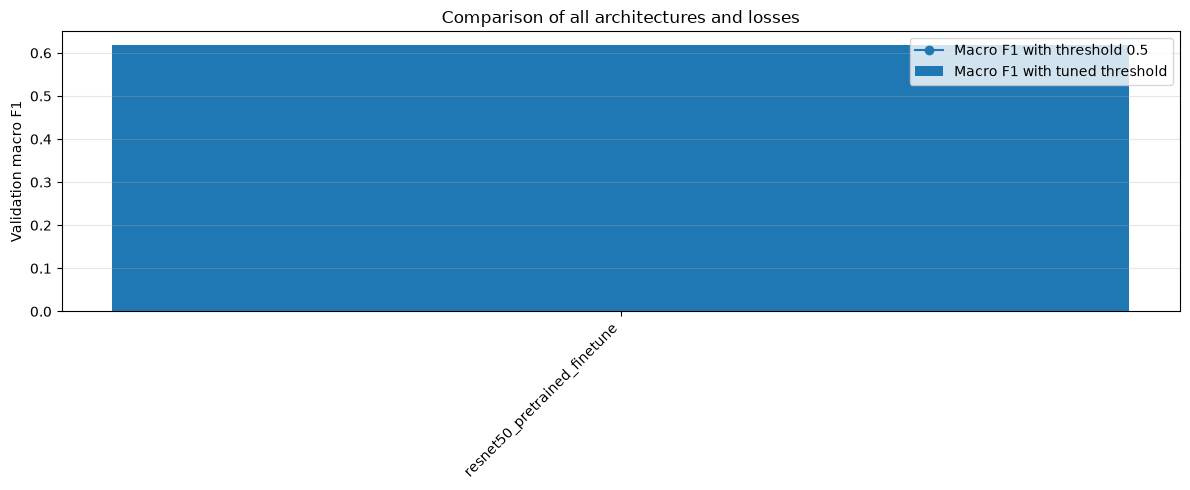

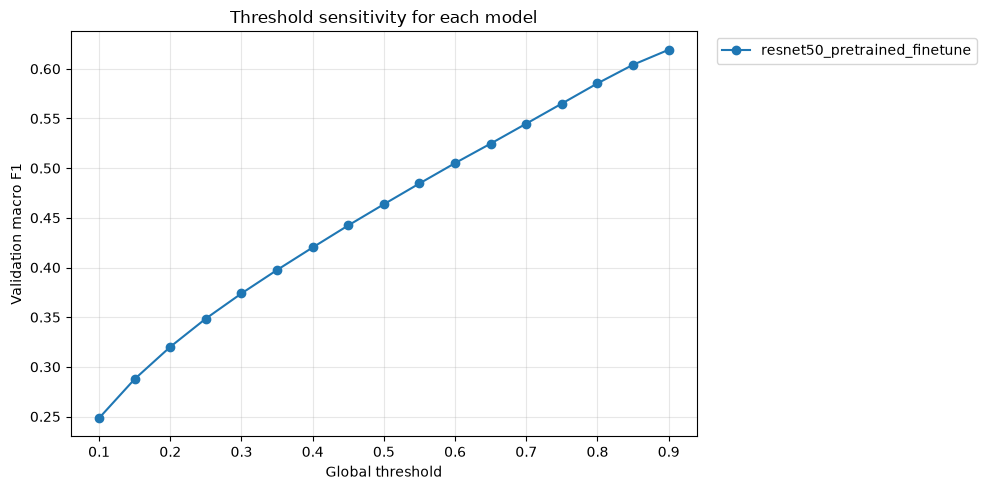

In [18]:
comparison_df = results_df.merge(
    threshold_results_df[["experiment", "best_threshold", "f1_leaderboard", "f1_macro"]],
    on="experiment", how="left", suffixes=("_at_0.5", "_tuned"),
).sort_values("f1_macro_tuned", ascending=False)

comparison_columns = ["experiment", "backbone", "pretrained", "freeze_backbone",
                      "f1_macro_at_0.5", "f1_macro_tuned", "f1_leaderboard", "best_threshold"]
display(comparison_df[[c for c in comparison_columns if c in comparison_df]])
comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)

plt.figure(figsize=(12, 5))
plt.bar(comparison_df["experiment"], comparison_df["f1_macro_tuned"], label="Macro F1 with tuned threshold")
plt.plot(comparison_df["experiment"], comparison_df["f1_macro_at_0.5"], "o-", label="Macro F1 with threshold 0.5")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Validation macro F1")
plt.title("Comparison of all architectures and losses")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for name, table in threshold_tables.items():
    plt.plot(table["threshold"], table["f1_macro"], marker="o", label=name)
plt.xlabel("Global threshold")
plt.ylabel("Validation macro F1")
plt.title("Threshold sensitivity for each model")
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 17. Score by number of classes per image

We take the validation predictions of one model (`MODEL_NAME`, by default the best configuration found above) and compute, for every validation image, the F1 score between its predicted classes and its true classes, using the tuned threshold of this model. Images are then grouped by their number of true classes to see whether the model struggles more on crowded scenes. The experiments (section 12) and the threshold tuning (section 14) must have been run in the same session.

Model : resnet50_pretrained_finetune | validation images : 9,750 | threshold : 0.90


,n_classes,mean_f1,images
0,1,0.803162,2021
1,2,0.716130,3043
2,3,0.646006,2023
3,4,0.611905,1142
4,5,0.566412,642
5,6,0.579523,399
6,7,0.547118,217
7,8,0.567573,122
8,9,0.614872,60
9,10,0.621550,46


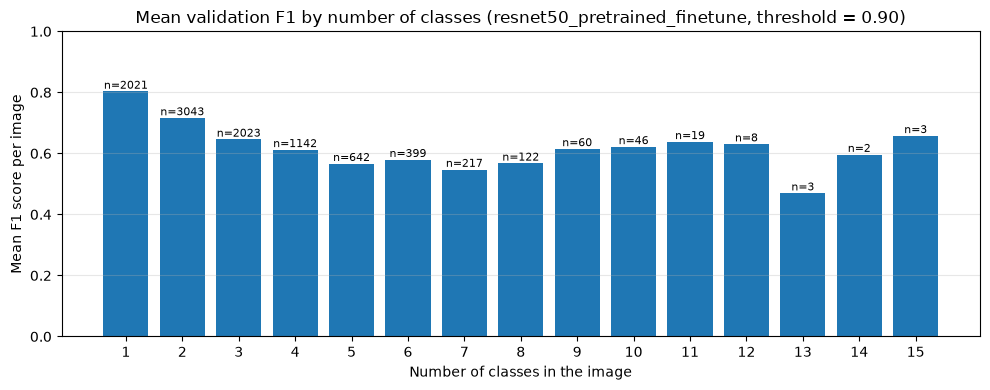

In [19]:
MODEL_NAME = best_name

y_val_model, p_val_model = prediction_cache[MODEL_NAME]
model_threshold = float(threshold_results_df.set_index("experiment").loc[MODEL_NAME, "best_threshold"])

print(f"Model : {MODEL_NAME} | validation images : {len(y_val_model):,} | threshold : {model_threshold:.2f}")

y_true_img = y_val_model.astype(bool)
y_pred_img = p_val_model >= model_threshold
n_classes_img = y_true_img.sum(axis=1)
tp_img = (y_true_img & y_pred_img).sum(axis=1)
f1_img = 2 * tp_img / (n_classes_img + y_pred_img.sum(axis=1))

score_by_n_classes = (pd.DataFrame({"n_classes": n_classes_img, "f1": f1_img})
                      .groupby("n_classes")["f1"].agg(mean_f1="mean", images="count").reset_index())
display(score_by_n_classes)
score_by_n_classes.to_csv(OUTPUT_DIR / f"{MODEL_NAME}_score_by_n_classes.csv", index=False)

plt.figure(figsize=(10, 4))
bars = plt.bar(score_by_n_classes["n_classes"], score_by_n_classes["mean_f1"])
plt.bar_label(bars, labels=[f"n={n}" for n in score_by_n_classes["images"]], fontsize=8)
plt.xticks(score_by_n_classes["n_classes"])
plt.ylim(0, 1)
plt.xlabel("Number of classes in the image")
plt.ylabel("Mean F1 score per image")
plt.title(f"Mean validation F1 by number of classes ({MODEL_NAME}, threshold = {model_threshold:.2f})")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Final submission generation

All architectures and loss functions are first evaluated and visualized on the validation set. This section is restricted to the best model and its selected threshold; no other model is implicitly used in the leaderboard submission.

In [ ]:
USE_PER_CLASS_THRESHOLDS = False
TEST_BATCH_SIZE = BATCH_SIZE
test_ds = COCOTestImageDataset(TEST_IMAGE_DIR, transform=val_transform)
test_loader = DataLoader(test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=NUM_WORKERS > 0)

best_model.eval()
output_dict = {}
with torch.no_grad():
    for images, image_ids in tqdm(test_loader, desc=f"test inference ({best_name})"):
        probs = torch.sigmoid(best_model(images.to(DEVICE))).cpu().numpy()
        if USE_PER_CLASS_THRESHOLDS:
            pred = probs >= per_class_thresholds[None, :]
        else:
            pred = probs >= best_global_threshold
        for image_id, row in zip(image_ids, pred):
            output_dict[image_id] = np.flatnonzero(row).astype(int).tolist()

json_path = OUTPUT_DIR / "submission.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(output_dict, f, ensure_ascii=False, indent=2)

print("JSON created :", json_path.resolve())
print("Model used :", best_name)
print("Number of predicted images :", len(output_dict))
print("Example :", next(iter(output_dict.items())) if output_dict else "empty")

## 19. Submission verification

We verify that the generated JSON file is valid, contains exactly the expected test image identifiers, and stores valid class predictions.

In [ ]:
with open(json_path, "r", encoding="utf-8") as f:
    submission_check = json.load(f)

expected_ids = {p.stem for p in TEST_IMAGE_DIR.glob("*.jpg") if p.is_file()}
submitted_ids = set(submission_check)
assert submitted_ids == expected_ids, (
    f"missing images: {len(expected_ids - submitted_ids)}, "
    f"unexpected images: {len(submitted_ids - expected_ids)}."
)
for image_id, ids in submission_check.items():
    assert isinstance(image_id, str)
    assert isinstance(ids, list)
    assert all(isinstance(i, int) and 0 <= i < NUM_CLASSES for i in ids), image_id
    assert len(ids) == len(set(ids)), f"duplicate identifier: {image_id}"
print("Submission verification succeeded.")
print("File ready for the leaderboard:", json_path.resolve())